In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# INSTALL ULTRALYTICS

In [3]:
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 100.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


# LOAD DATASET


In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key="zt49meyUQZK7ElhQ4HPh")
project = rf.workspace("phan-vn-khi").project("dataset-usskc")
version = project.version(1)
dataset = version.download("yolov8")
!unzip -q /content/dataset-1/roboflow.zip -d /content/dataset-1/

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dataset-1 in yolov8:: 100%|██████████| 18838/18838 [00:02<00:00, 7177.50it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
unzip:  cannot find or open /content/dataset-1/roboflow.zip, /content/dataset-1/roboflow.zip.zip or /content/dataset-1/roboflow.zip.ZIP.


# TRAIN MODEL

In [6]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
model.train(data='/content/dataset-1/data.yaml',
            epochs=40,
            batch=32,
            mosaic=1.0,
            degrees=10.0,
            scale=0.5,
            translate=0.1,
            hsv_v=0.4,
            hsv_s=0.7,
            optimizer='AdamW')

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset-1/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cf59697b110>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [7]:
import os

# Duyệt thư mục /content/runs/detect
base_path = "/content/runs/detect"
for root, dirs, files in os.walk(base_path):
    if "best.pt" in files:
        print("Found best.pt at:", os.path.join(root, "best.pt"))

Found best.pt at: /content/runs/detect/train/weights/best.pt


In [9]:
from google.colab import files
!zip -r runs.zip /content/runs
files.download('runs.zip')

updating: content/runs/ (stored 0%)
updating: content/runs/detect/ (stored 0%)
updating: content/runs/detect/train/ (stored 0%)
updating: content/runs/detect/train/val_batch2_labels.jpg (deflated 5%)
updating: content/runs/detect/train/val_batch0_pred.jpg (deflated 12%)
updating: content/runs/detect/train/train_batch1.jpg (deflated 3%)
updating: content/runs/detect/train/results.png (deflated 8%)
updating: content/runs/detect/train/val_batch0_labels.jpg (deflated 13%)
updating: content/runs/detect/train/train_batch7680.jpg (deflated 9%)
updating: content/runs/detect/train/train_batch7682.jpg (deflated 5%)
updating: content/runs/detect/train/train_batch7681.jpg (deflated 6%)
updating: content/runs/detect/train/BoxF1_curve.png (deflated 6%)
updating: content/runs/detect/train/weights/ (stored 0%)
updating: content/runs/detect/train/weights/best.pt (deflated 9%)
updating: content/runs/detect/train/weights/last.pt (deflated 9%)
updating: content/runs/detect/train/val_batch2_pred.jpg (defla

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
from PIL import Image
best_model = YOLO('/content/runs/detect/train/weights/best.pt')
result = best_model.predict(source='/content/1024px-Banana_peel_on_the_ground.jpg')
for r in result:
  print(r.boxes)
  im_array = r.plot()  # plot a BGR numpy array of predictions
  im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
  im.show()  # show image
  im.save('result.jpg')  # save image

# Show ảnh nhưng không được nên sẽ dùng matplotlib


image 1/1 /content/1024px-Banana_peel_on_the_ground.jpg: 448x640 2 banana-peels, 39.9ms
Speed: 2.6ms preprocess, 39.9ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0.], device='cuda:0')
conf: tensor([0.7981, 0.4603], device='cuda:0')
data: tensor([[4.1637e+02, 2.5590e+02, 9.6157e+02, 4.2900e+02, 7.9810e-01, 0.0000e+00],
        [5.3884e+02, 2.5977e+02, 1.0219e+03, 4.2821e+02, 4.6025e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (683, 1024)
shape: torch.Size([2, 6])
xywh: tensor([[688.9710, 342.4500, 545.1921, 173.1071],
        [780.3948, 343.9919, 483.1087, 168.4358]], device='cuda:0')
xywhn: tensor([[0.6728, 0.5014, 0.5324, 0.2535],
        [0.7621, 0.5036, 0.4718, 0.2466]], device='cuda:0')
xyxy: tensor([[ 416.3749,  255.8964,  961.5671,  429.0035],
        [ 538.8405,  259.7740, 1021.9492,  428.2098]], device='cuda:0')
xyxyn: tensor([[0.4066, 0.3747, 0.9390, 0


image 1/1 /content/1024px-Banana_peel_on_the_ground.jpg: 448x640 2 banana-peels, 16.9ms
Speed: 2.9ms preprocess, 16.9ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0.], device='cuda:0')
conf: tensor([0.7981, 0.4603], device='cuda:0')
data: tensor([[4.1637e+02, 2.5590e+02, 9.6157e+02, 4.2900e+02, 7.9810e-01, 0.0000e+00],
        [5.3884e+02, 2.5977e+02, 1.0219e+03, 4.2821e+02, 4.6025e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (683, 1024)
shape: torch.Size([2, 6])
xywh: tensor([[688.9710, 342.4500, 545.1921, 173.1071],
        [780.3948, 343.9919, 483.1087, 168.4358]], device='cuda:0')
xywhn: tensor([[0.6728, 0.5014, 0.5324, 0.2535],
        [0.7621, 0.5036, 0.4718, 0.2466]], device='cuda:0')
xyxy: tensor([[ 416.3749,  255.8964,  961.5671,  429.0035],
        [ 538.8405,  259.7740, 1021.9492,  428.2098]], device='cuda:0')
xyxyn: tensor([[0.4066, 0.3747, 0.9390, 0

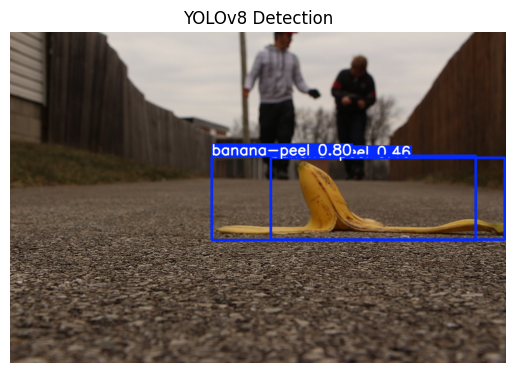

In [15]:
from matplotlib import pyplot as plt
best_model = YOLO('/content/runs/detect/train/weights/best.pt')
result = best_model.predict(source='/content/1024px-Banana_peel_on_the_ground.jpg')
for r in result:
    print(r.boxes)  # In thông tin bounding boxes

    im_array = r.plot()  # BGR array với bounding box
    im_rgb = im_array[..., ::-1]  # Chuyển từ BGR -> RGB

    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title("YOLOv8 Detection")
    plt.show()

    # Lưu ảnh nếu cần
    #Image.fromarray(im_rgb).save('result.jpg')

# ĐÁNH GIÁ KẾT QUẢ TRÊN TẬP TEST

In [12]:
metrics = model.val(
    data='/content/dataset-1/data.yaml',  # YAML chứa đường dẫn test set
    split='test',                      # Đánh giá trên tập test
)

f1_array = metrics.box.f1
mean_f1 = f1_array.mean()
# Hiển thị kết quả đánh giá
print("\nEvaluation Metrics:")
print(f"Precision (mean): {metrics.box.p.mean():.4f}") # tỉ lệ phát hiện đối tượng thực sự có mặt
print(f"Recall (mean): {metrics.box.r.mean():.4f}") # tỉ lệ dự đoán đúng trong mỗi lần có đối tượng
print(f"F1-Score trung bình: {mean_f1:.4f}")
print(f"mAP@0.5: {metrics.box.ap50.mean():.4f}")
print(f"mAP@0.5:0.95: {metrics.box.ap.mean():.4f}")

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 25.4±12.6 MB/s, size: 52.1 KB)
val: Scanning /content/dataset-1/test/labels... 616 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 616/616 898.0it/s 0.7s
val: New cache created: /content/dataset-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 5.7it/s 6.9s
                   all        616        683      0.841      0.785      0.865      0.748
           banana-peel         97        102      0.849      0.814      0.867      0.653
                 glass         75         75      0.894      0.791      0.932       0.82
                 metal         87         87      0.743      0.908      0.847      0.806
           orange-peel         82        127      0.815       0.78      0.886      0.

In [13]:
results = model.predict(
    source='/content/dataset-1/test/images', # Đường dẫn folder ảnh
    conf=0.25,      # Ngưỡng tin cậy
    save=True,      # Lưu ảnh đã vẽ box
    line_width=2    # Độ dày nét vẽ
)

print("Ảnh kết quả đã được lưu tại: runs/detect/predict")


image 1/616 /content/dataset-1/test/images/20211206_165056_jpg.rf.8550bdcfe7ac97c9100aebf1cd04b32f.jpg: 640x640 1 banana-peel, 22.6ms
image 2/616 /content/dataset-1/test/images/20211206_220726_jpg.rf.6602b8ea40cebbdb523b3366ed49bd7c.jpg: 640x640 1 metal, 1 paper, 29.0ms
image 3/616 /content/dataset-1/test/images/20211206_220830_jpg.rf.b83342fdb2208abadec6e5d399e014db.jpg: 640x640 2 banana-peels, 16.0ms
image 4/616 /content/dataset-1/test/images/20211206_220838_jpg.rf.5d697eb7cbf10a8fdc143c31e50c41cf.jpg: 640x640 2 banana-peels, 29.5ms
image 5/616 /content/dataset-1/test/images/20211206_220930_jpg.rf.c8856d0f81c3a3184da7b838c9f7c7b6.jpg: 640x640 1 banana-peel, 31.3ms
image 6/616 /content/dataset-1/test/images/20211206_221126_jpg.rf.f932d546225ed3cb5ff4c3b68d5c5252.jpg: 640x640 3 banana-peels, 11.0ms
image 7/616 /content/dataset-1/test/images/20211206_221219_jpg.rf.c21cd951993058e18fe22ad6330afa59.jpg: 640x640 1 banana-peel, 15.9ms
image 8/616 /content/dataset-1/test/images/20211206_221

In [ ]:
!cp /content/runs/detect/train/weights/best.pt "/content/drive/MyDrive/An Nguyen/"


cp: cannot create regular file '/content/drive/MyDrive/An Nguyen/': Not a directory
